# Predicting Customer Churn for SyriaTel

## 1. Business Understanding
Syriatel has been facing a surge in the number of customer switching to their competitor TelCall. This is also called churning where customers leave the company for one reason or another.

This high rate of churning leads to loss of revenue to Syriatel. They are now interested in reducing the number of customers lost by figuring out if there are any predictable patterns before customers churn to try and minimize the churn rate and regain their revenue as well.

## 1.1 Problem Statement
SyriaTel are on a mission to figure out why a lot of their customers are churning and come up with recommendations to retain them. They thus want to **identify the patterns and reasons as to why people leave abandon their services**. This way they can start brainstorming how to retain their customers and even attract more.

## 1.2 Objectives
The objective of this project is to identify the patterns and predict whether a customer will eventually halt doing business with SyriaTel.
We will thus have to build a binary classification model which will return:
- "Yes" if a customer churns,
- "No" if a customer stays at the company

This will help SyriaTel to:
- Identify reasons why customers are leaving their company.
- Identify what needs to be changed to retain their customer base.

## 1.3 Metrics of Success
The project will be termed as successful when:
- We have made a machine learning model that correctly predicts whether a customer churns.
- Develop a strealit frontend application that a Business Intelligence Analyst can enter parameters in and figure out if someone will churn.
- We achieve an accuracy score of at least 90%.
- We achieve a precision score of 90%.

# 2. Data Understanding
This dataset is sourced from [Kaggle](https://www.kaggle.com/datasets/becksddf/churn-in-telecoms-dataset).

The dataset contains one table with 21 columns
- **state** - the state where the customer resides in in the United States.
- **account length** - duration in days the customer has had the account.
- **area code** - telephone area code where the customer resides in.
- **phone number** - telephone number of the customer.
- **international plan** - whether a customer has an international plan (Yes/No).
- **voice mail plan** - whether a customer has a voice mail plan (Yes/No).
- **number vmail messages** - number of voicemail messages received by the customers.
- **total day minutes** - total minutes made by a customer during the day.
- **total day calls** - total number of calls made by a customer during the day.
- **total day charge** - total cost of calls made during the day.
- **total eve minutes** - total minutes made by a customer in the evening.
- **total eve calls** - total number of calls made by a cutomer in the evening.
- **total eve charge** - total cost of calls made in the evening.
- **total night minutes** - total minutes made by a customer in the night.
- **total night calls** - total number of calls made by a cutomer in the night.
- **total night charge** - total cost of calls made in the night.
- **total intl minutes** - total international minutes made by a customer.
- **total intl calls** - total number of international calls made by a cutomer.
- **total intl charge** - total cost of international calls.
- **customer service calls** - number of calls made by a customer to customer care support.
- **churn** - whether the customer leaves the company - churns (Yes/No)

In [1]:
# Importing necessary libraries
import numpy as np
import pandas as pd

# To show all columns
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading and previewing the dataset
df = pd.read_csv("data.csv")

# Top 5 rows
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
#Bottom 5 rows
df.tail()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
3328,AZ,192,415,414-4276,no,yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,WV,68,415,370-3271,no,no,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,RI,28,510,328-8230,no,no,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,CT,184,510,364-6381,yes,no,0,213.8,105,36.35,159.6,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False
3332,TN,74,415,400-4344,no,yes,25,234.4,113,39.85,265.9,82,22.60,241.4,77,10.86,13.7,4,3.70,0,False


**Observation**

The dataset is uniform from start to finish

In [4]:
# Dataset shape
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns")

The dataset contains 3333 rows and 21 columns


In [5]:
# Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

**Observation**

- The dataset has 16 numerical columns and 5 categorical columns.
- There are no null values in the dataset.

In [6]:
# Statistical Summary
df.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


**Observation**

- On average, a customer stays around 101 days with the company. The most someone has ever stayed at the company is 243 days.
- On average, the average number of calls made during the day, evening and night is almost the same at 100 calls

In [7]:
# Statistical summary for categorical columns
df.describe(include = "object")

,state,phone number,international plan,voice mail plan
count,3333,3333,3333,3333
unique,51,3333,2,2
top,WV,382-4657,no,no
freq,106,1,3010,2411


**Observation**
- Most of the customers from SyriaTel are from the state of West Virginia.
- All the phone numbers in our dataset are unique. There are no duplicate customers in the dataset.
- Almost all of the customers do not have an international plan.
- Most of our customers also do not have a voice mail plan

In [8]:
# Checking for unique values
for col in df:
    unique_values = df[col].unique()
    print(f"{col}\n, {unique_values}\n")

state
, ['KS' 'OH' 'NJ' 'OK' 'AL' 'MA' 'MO' 'LA' 'WV' 'IN' 'RI' 'IA' 'MT' 'NY'
 'ID' 'VT' 'VA' 'TX' 'FL' 'CO' 'AZ' 'SC' 'NE' 'WY' 'HI' 'IL' 'NH' 'GA'
 'AK' 'MD' 'AR' 'WI' 'OR' 'MI' 'DE' 'UT' 'CA' 'MN' 'SD' 'NC' 'WA' 'NM'
 'NV' 'DC' 'KY' 'ME' 'MS' 'TN' 'PA' 'CT' 'ND']

account length
, [128 107 137  84  75 118 121 147 117 141  65  74 168  95  62 161  85  93
  76  73  77 130 111 132 174  57  54  20  49 142 172  12  72  36  78 136
 149  98 135  34 160  64  59 119  97  52  60  10  96  87  81  68 125 116
  38  40  43 113 126 150 138 162  90  50  82 144  46  70  55 106  94 155
  80 104  99 120 108 122 157 103  63 112  41 193  61  92 131 163  91 127
 110 140  83 145  56 151 139   6 115 146 185 148  32  25 179  67  19 170
 164  51 208  53 105  66  86  35  88 123  45 100 215  22  33 114  24 101
 143  48  71 167  89 199 166 158 196 209  16  39 173 129  44  79  31 124
  37 159 194 154  21 133 224  58  11 109 102 165  18  30 176  47 190 152
  26  69 186 171  28 153 169  13  27   3  42 189 156 134 

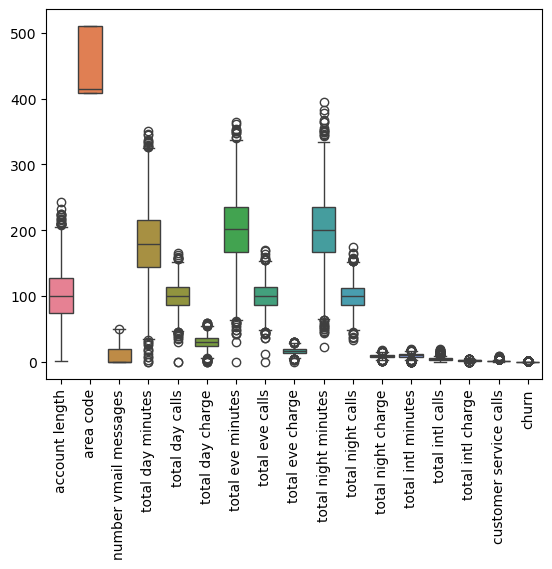

In [9]:
# Checking for outliers
sns.boxplot(df)
plt.xticks(rotation = 90);

**Observation**
- Even though there seems to be quite a lot of outliers, they are all genuine outliers. They shall not be removed.

# 3. Data Preparation